<a href="https://colab.research.google.com/github/OlhaZahrebelna/python_for_ds_task/blob/main/ZahrebelnaOlha_%22HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# зниження розмірності
from sklearn.decomposition import PCA

# кластеризація
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# метрики
from sklearn.metrics import silhouette_score



In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
print(f'Кількість рядків: {df.shape[0]}')
print(f'Кількість пропущених значень: {df.isna().sum().sum()}')

Кількість рядків: 2240
Кількість пропущених значень: 24


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [6]:
df.nunique()

,0
ID,2240
Year_Birth,59
Education,5
Marital_Status,8
Income,1974
Kidhome,3
Teenhome,3
Dt_Customer,663
Recency,100
MntWines,776


<Axes: ylabel='Frequency'>

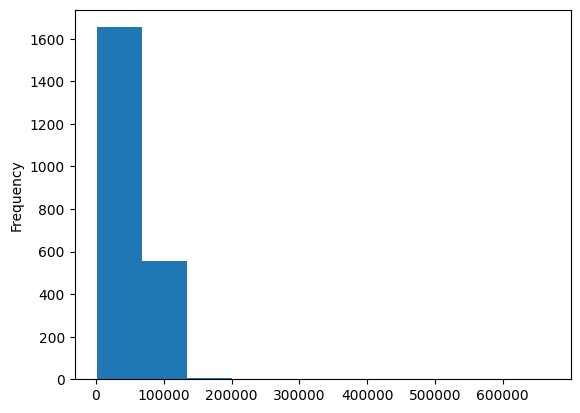

In [7]:
df['Income'].plot(kind='hist')

In [8]:
print(max(df['Income']))
print(min(df['Income']))

666666.0
1730.0


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [9]:
df['Income'].fillna(df['Income'].median(), inplace=True)

In [10]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


У даних присутні викиди, тому середнє значення зміщується. Медіана є більш стабільною характеристикою розподілу, тому використовується для заповнення пропусків у колонці Income.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [11]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [12]:
df['Dt_Customer'].dtype

dtype('<M8[ns]')

In [13]:
reference_date = df['Dt_Customer'].max()
df['Customer_days'] = (reference_date - df['Dt_Customer']).dt.days

In [14]:
df['Customer_days'].head()

,Customer_days
0,663
1,113
2,312
3,139
4,161


In [15]:
df.nunique()

,0
ID,2240
Year_Birth,59
Education,5
Marital_Status,8
Income,1975
Kidhome,3
Teenhome,3
Dt_Customer,663
Recency,100
MntWines,776


In [16]:
df = df.drop(columns=['Dt_Customer','ID','Z_CostContact', 'Z_Revenue'])

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Customer_days'],
      dtype='object')
Index(['Education', 'Marital_Status'], dtype='object')


In [18]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [19]:
X = preprocessor.fit_transform(df)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [20]:
print(df['Cluster'].value_counts())

Cluster
0    1048
1     640
2     552
Name: count, dtype: int64


In [21]:
type(X)

numpy.ndarray

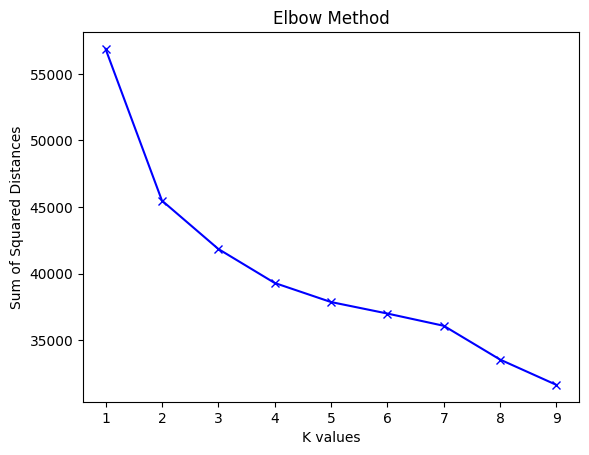

In [22]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [23]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'k={k}, silhouette={score}')

k=2, silhouette=0.23511312678892748
k=3, silhouette=0.16275487424190663
k=4, silhouette=0.16333805333258483
k=5, silhouette=0.14753988012844726
k=6, silhouette=0.1540242340613397
k=7, silhouette=0.09843492312853443
k=8, silhouette=0.09660489695100219
k=9, silhouette=0.10098019259004576


In [24]:
score = silhouette_score(X, df['Cluster'])
print(f'Silhouette score: {score}')

Silhouette score: 0.16275487424190663


Низка оцінка, це значить, що погано кластеризували.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [25]:
df['Total_Spending'] = df[
    ['MntWines','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
].sum(axis=1)

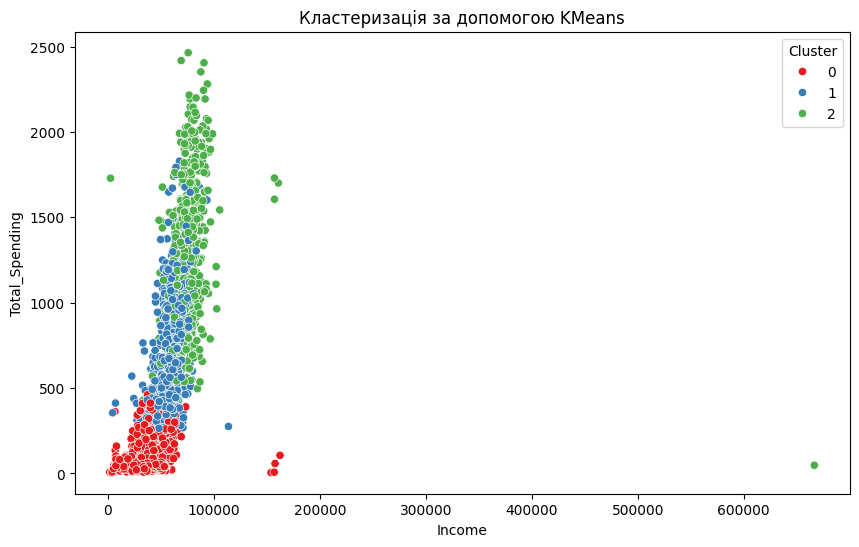

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Total_Spending', hue='Cluster', data=df, palette='Set1')
plt.title('Кластеризація за допомогою KMeans')
plt.show()

In [27]:
features = [
    'Income',
    'Total_Spending',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases',
    'Customer_days'
]

In [28]:
X = df[features]

In [29]:
fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='NumWebPurchases',
    color='Cluster',
    symbol='Cluster',
    opacity=0.7)
fig.show()

В результаті кластеризації клієнтів було виділено три сегменти, які відрізняються за рівнем доходу та обсягом витрат.
Найбільш чітке розділення спостерігається між клієнтами з низькими та високими витратами.
Водночас кластери частково перекриваються, що підтверджується низьким значенням silhouette score (~0.16). Це свідчить про те, що межі між сегментами є розмитими, а поведінка клієнтів має безперервний характер.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [30]:
X_scaled = StandardScaler().fit_transform(df[features])

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
df['Cluster_scaled'] = kmeans_scaled.fit_predict(X_scaled)

score_scaled = silhouette_score(X_scaled, df['Cluster_scaled'])
print(f'Silhouette score after scaling: {score_scaled}')

Silhouette score after scaling: 0.310059120555462


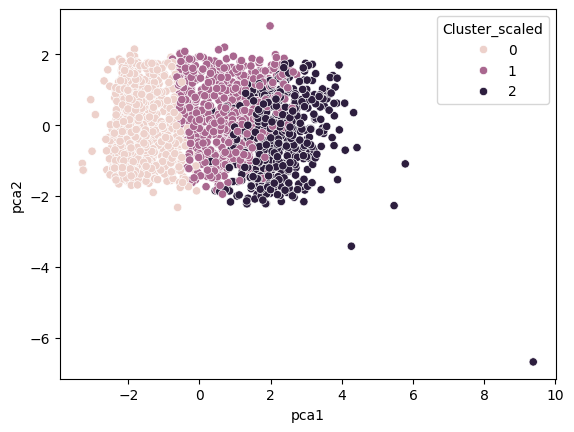

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

sns.scatterplot(x='pca1', y='pca2', hue='Cluster_scaled', data=df)
plt.show()

Після масштабування ознак за допомогою StandardScaler якість кластеризації покращилась. Значення silhouette score зросло з приблизно 0.16 до 0.31, що свідчить про краще відокремлення кластерів. Це пояснюється тим, що KMeans використовує евклідову відстань і чутливий до масштабу ознак. Без масштабування ознаки з великими числовими значеннями мали надмірний вплив на формування кластерів.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [32]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Income'] < lower) | (df['Income'] > upper)]
print(len(outliers))

8


In [33]:
df_clean = df[(df['Income'] >= lower) & (df['Income'] <= upper)]

In [34]:
df = df_clean.copy()

In [35]:
X_scaled = StandardScaler().fit_transform(df[features])

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
df['Cluster_scaled'] = kmeans_scaled.fit_predict(X_scaled)

score_scaled = silhouette_score(X_scaled, df['Cluster_scaled'])
print(f'Silhouette score after scaling: {score_scaled}')

Silhouette score after scaling: 0.34562576499723036


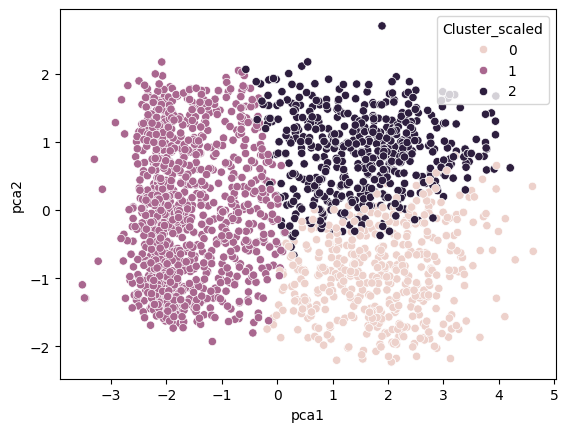

In [36]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

sns.scatterplot(x='pca1', y='pca2', hue='Cluster_scaled', data=df)
plt.show()

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

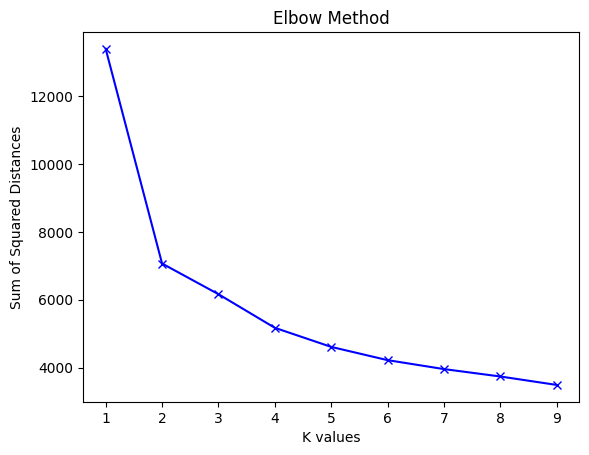

In [37]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [38]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'k={k}, silhouette={score}')

k=2, silhouette=0.415921542052141
k=3, silhouette=0.34562576499723036
k=4, silhouette=0.25342436232238214
k=5, silhouette=0.25443012149859107
k=6, silhouette=0.2526069254148084
k=7, silhouette=0.24682076558268667
k=8, silhouette=0.24381824181407258
k=9, silhouette=0.2502748174145445


За результатами Elbow методу оптимальна кількість кластерів становить 3, оскільки після цього значення зменшення сумарної внутрішньокластерної відстані сповільнюється.
Водночас аналіз silhouette score показав, що найвище значення (≈0.42) досягається при k=2, що свідчить про краще розділення кластерів у цьому випадку.
Таким чином, спостерігається розбіжність між методами: Elbow рекомендує k=3 для більш детальної сегментації, тоді як silhouette — k=2 для більш чітко відокремлених кластерів.
У даній роботі доцільно обрати k=3, оскільки це дозволяє отримати більш інформативну сегментацію клієнтів, навіть якщо розділення між кластерами є менш чітким.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

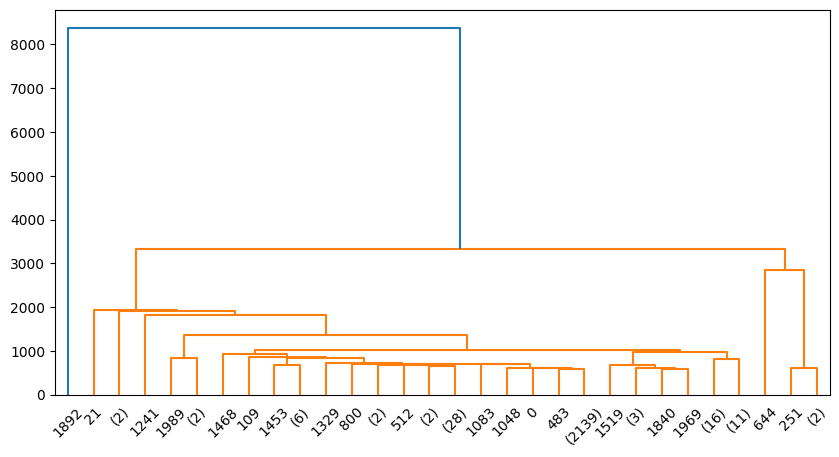

In [39]:
sing_link = linkage(df_clean[features], method='single')
plt.figure(figsize=(10, 5))
dendrogram(sing_link, truncate_mode='lastp')
plt.show()

In [40]:
clusters_2 = fcluster(sing_link, 2, criterion='maxclust')
clusters_3 = fcluster(sing_link, 3, criterion='maxclust')

In [41]:
df_clean['Hier_2'] = clusters_2
df_clean['Hier_3'] = clusters_3

<Axes: xlabel='Income', ylabel='Total_Spending'>

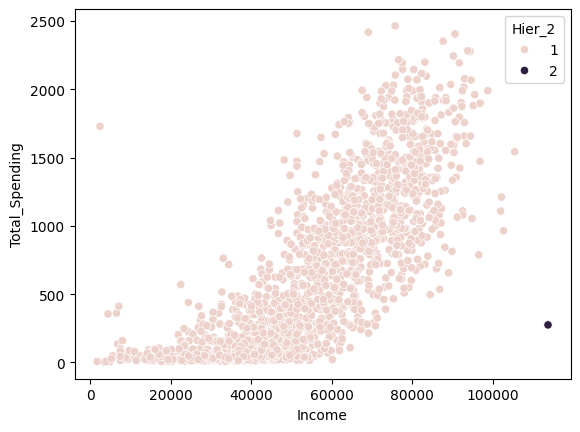

In [42]:
sns.scatterplot(data=df_clean, x='Income', y='Total_Spending', hue='Hier_2')

<Axes: xlabel='Income', ylabel='Total_Spending'>

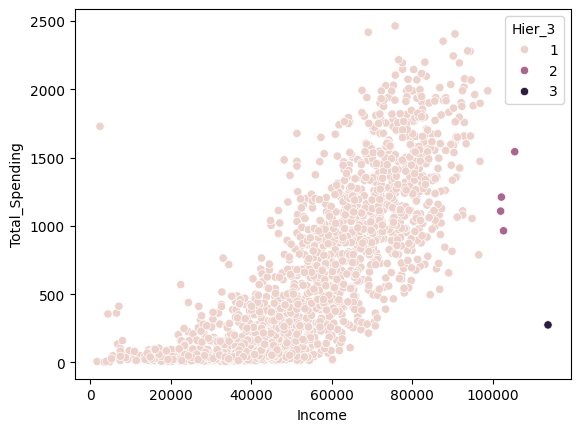

In [43]:
sns.scatterplot(data=df_clean, x='Income', y='Total_Spending', hue='Hier_3')

In [44]:
score_2 = silhouette_score(df_clean[features], clusters_2)
score_3 = silhouette_score(df_clean[features], clusters_3)

print(score_2, score_3)

0.5572907124878645 0.45041182531927987


Ієрархічна кластеризація методом single linkage показала наявність ефекту "ланцюжка" (chaining effect), при якому об'єкти послідовно об’єднуються за найменшою відстанню. У результаті формується один великий кластер і кілька малих груп або окремих точок.
При побудові кластерів на 2 та 3 групи не спостерігається чіткого поділу даних на змістовні сегменти — більшість об'єктів потрапляє до одного кластера, тоді як інші представляють лише окремі крайні значення.
Хоча значення silhouette score є відносно високими (≈0.56 для 2 кластерів), це пояснюється простою структурою даних (великий кластер + невеликі відокремлені точки), а не якісною сегментацією.
Таким чином, метод single linkage не є оптимальним для даного набору даних, і KMeans демонструє більш інформативні результати кластеризації.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

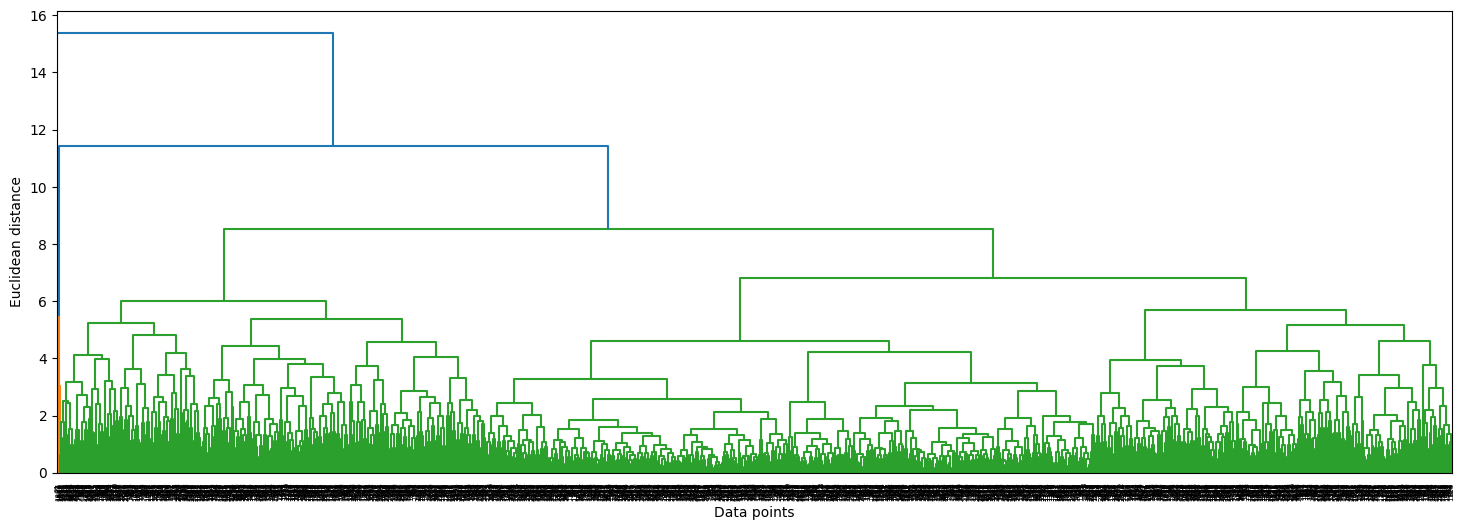

In [45]:
dist_comp = linkage(X_scaled, method="complete")

plt.figure(figsize=(18,6))
dendrogram(dist_comp, leaf_rotation=90)
plt.xlabel("Data points")
plt.ylabel("Euclidean distance")
plt.show()



In [46]:
clusters = fcluster(dist_comp, t=3, criterion='maxclust')

score = silhouette_score(X_scaled, clusters)
print(score)

0.62928209577465


Для додаткового аналізу було використано ієрархічну кластеризацію з методом complete linkage. На відміну від single linkage, цей метод формує більш компактні та добре відокремлені кластери, оскільки враховує максимальну відстань між елементами кластерів.
Кластеризація проводилась на масштабованих даних, що дозволило уникнути домінування ознак з великим масштабом.
За результатами обчислення silhouette score було отримано значення ≈0.63, що є значно вищим порівняно з попередніми методами. Це свідчить про кращу якість кластеризації та чіткіше розділення кластерів.
Таким чином, метод complete linkage виявився найбільш ефективним серед розглянутих підходів і може бути рекомендований для сегментації клієнтів у даному наборі даних.